<h3>Introduction</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

    
#### What are Inverse PINNs (iPINNs)?
A class of **Scientific Machine Learning (SciML)** that embeds governing equations (ODEs/PDEs) into the loss function to infer unknown parameters from data.

* **Forward PINNs:** Given parameters & equations $\rightarrow$ solve for **state variables**.
* **Inverse PINNs:** Given physical laws & sparse/noisy data $\rightarrow$ estimate **unknown parameters & degradation rates**.

---

#### Key Capabilities/Usage:
- Parameter Recovery & Inference *(e.g., calendar ageing kinetic parameters)*
- System Identification *(discovering governing terms/fields)*
- Robustness with Sparse & Noisy Data
- Uncertainty Quantification

<h3>Overview</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

In this project, I demonstrate the use of an **Inverse Physics-Informed Neural Network (iPINN)** to identify battery calendar-ageing degradation parameters directly from sparse experimental data.

Unlike conventional machine learning models that focus solely on fitting observed measurements, the iPINN incorporates a physically motivated degradation model into the training process. By combining experimental capacity-loss data with known battery ageing physics, the network is constrained to learn solutions that are both data-consistent and physically meaningful.

The objective is not only to predict battery degradation but also to discover hidden degradation parameters governing the ageing process. In particular, the model learns temperature-dependent degradation rates associated with SEI growth and long-term ageing mechanisms directly from the data.

This demonstrates how physics-informed machine learning can move beyond curve fitting and serve as a powerful framework for **parameter discovery, model interpretation, and scientific understanding**, especially in engineering applications where data is often sparse but the underlying physics is reasonably well understood.

<h3>Problem Statement</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

Battery calendar ageing is strongly influenced by storage temperature. Engineers often require degradation-rate parameters to:

- Predict and forecast battery lifetime
- Understand underlying ageing mechanisms
- Compare battery performance across different operating conditions

Traditional machine learning approaches typically require large amounts of data and are often criticized as **black-box models** with limited physical interpretability. On the other hand, classical curve-fitting methods can match experimental observations but do not explicitly enforce the underlying physics governing the degradation process.

This project investigates whether an **Inverse Physics-Informed Neural Network (iPINN)** can accurately recover battery degradation parameters directly from sparse experimental observations while maintaining physical consistency with established battery-ageing theory.

<h3>Dataset</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

The experimental data used in this **Inverse Physics-Informed Neural Network (iPINN)** demonstration corresponds to calendar-ageing measurements of a commercial **Lithium Iron Phosphate (LFP)** cell. The objective of the original study was to investigate the impact of **storage temperature** on battery degradation under high State-of-Charge (SoC) conditions.

### Cell Specifications

The experiments were performed on a commercial **Sony US26650FTC1** cell designed for stationary energy-storage applications.

#### Cell Characteristics

- **Format:** 26650 Cylindrical Cell
- **Chemistry:** Lithium Iron Phosphate (LiFePO₄)
- **Nominal Capacity:** 3000 mAh
- **Nominal Voltage:** 3.2 V
- **Operating Voltage Range:** 2.0 V to 3.6 V

---

### Calendar Ageing Test Conditions

- **Storage State:** Constant 100% State of Charge (SoC)
- **Temperature Matrix:** 15°C, 25°C, 35°C, and 45°C
- **Time Span:** Day 0 to approximately Day 235 (sparse observation checkpoints)

The original study reports **capacity loss** over time. For the iPINN implementation, the data was converted to **remaining capacity**, which serves as the target variable for the neural network:

```text
Q = 1 - Loss
```

where:

- **Q** = Remaining normalized capacity
- **Loss** = Measured capacity fade

Using remaining capacity instead of capacity loss allows the network to directly model battery **State-of-Health (SoH)** evolution while simultaneously enforcing the underlying degradation physics through the PINN framework.

---

### Source

The experimental data was extracted from:

> Naumann, M. et al., *Analysis and Modeling of Calendar Aging of a Commercial LiFePO₄/Graphite Cell*, Journal of The Electrochemical Society.

📄 **Paper:**  
https://iopscience.iop.org/article/10.1149/2.1181714jes

<h3>Let's Walk through the code!!</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">
Lets look at the experimental datapoints for 4 different cells and observe the degradation trend


In [149]:
# ============================================================
# 1. Library Import and Experimental Data
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Experimental Data (Converted from MATLAB to PyTorch Tensors)
# Time vector (days)
time_days = [0, 7, 18, 32, 51, 73, 103, 121, 154, 196, 235]
t_data = torch.tensor(time_days, dtype=torch.float32).unsqueeze(1)

# Capacity Loss data at different temperatures
loss_15C = [0.000, 0.030, 0.040, 0.051, 0.062, 0.067, 0.085, 0.088, 0.089, 0.105, 0.112]
loss_25C = [0.000, 0.038, 0.050, 0.063, 0.077, 0.086, 0.103, 0.112, 0.108, 0.130, 0.139]
loss_35C = [0.000, 0.043, 0.063, 0.080, 0.097, 0.113, 0.127, 0.140, 0.153, 0.165, 0.178]
loss_45C = [0.000, 0.054, 0.078, 0.099, 0.128, 0.150, 0.176, 0.188, 0.209, 0.226, 0.244]

# Convert to Capacity Remaining (Q = 1 - Loss)
def to_q_tensor(loss_list):
    return 1.0 - torch.tensor(loss_list, dtype=torch.float32).unsqueeze(1)

q_true = [
    to_q_tensor(loss_15C),
    to_q_tensor(loss_25C),
    to_q_tensor(loss_35C),
    to_q_tensor(loss_45C)
]

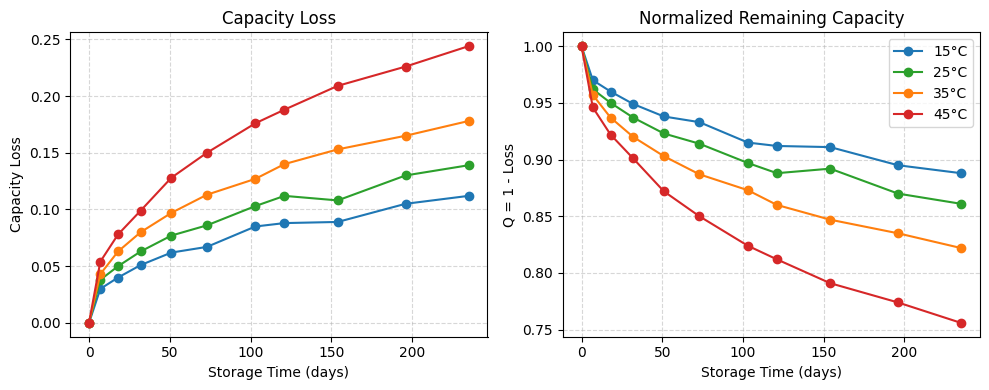

In [150]:
# ============================================================
# 2. Plotting the Raw Data
# ============================================================
loss_data = [loss_15C, loss_25C, loss_35C, loss_45C]
colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]
labels = ["15°C", "25°C", "35°C", "45°C"]

fig, ax = plt.subplots(1, 2, figsize=(10,4))

for loss, q, c, lbl in zip(loss_data, q_true, colors, labels):

    # Capacity loss
    ax[0].plot(time_days, loss, "o-", color=c, label=lbl)

    # Remaining capacity
    ax[1].plot(time_days,
               q.numpy().flatten(),
               "o-", color=c, label=lbl)

ax[0].set_title("Capacity Loss")
ax[0].set_xlabel("Storage Time (days)")
ax[0].set_ylabel("Capacity Loss")
ax[0].grid(True, ls="--", alpha=0.5)

ax[1].set_title("Normalized Remaining Capacity")
ax[1].set_xlabel("Storage Time (days)")
ax[1].set_ylabel("Q = 1 - Loss")
ax[1].grid(True, ls="--", alpha=0.5)

ax[1].legend()
plt.tight_layout()
plt.show()

In [151]:
# ============================================================
# 3. Defining the PINN Architechture
# ============================================================
class BatteryPINN(nn.Module):
    def __init__(self):
        super().__init__()

        # 1 input (time) -> 4 outputs (Q at 15°C, 25°C, 35°C, and 45°C)
        self.t_max = 235.0
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 4)
        )

        # Inverse PINN: learn SEI and linear-ageing rates for each temperature
        self.k_raw = nn.Parameter(torch.full((4,), -5.3))
        self.b_raw = nn.Parameter(torch.full((4,), -9.0))

    @property
    def k(self):
        return F.softplus(self.k_raw)  # Positive SEI rates

    @property
    def b(self):
        return F.softplus(self.b_raw)  # Positive linear-ageing rates

    def forward(self, t):
        return self.net(t / self.t_max)

<h3>PINN Architechture</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

The PINN takes **storage time** as input and simultaneously predicts the **remaining battery capacity** for four storage temperatures (15°C, 25°C, 35°C, and 45°C).

In addition to the neural-network weights, the model treats the **SEI degradation rates (k)** and **linear-ageing rates (b)** as trainable parameters, enabling inverse parameter discovery directly from experimental data.

The `softplus` transformation ensures that all learned degradation rates remain physically meaningful (positive), while time normalization improves training stability and convergence.

In [152]:
# ============================================================
# 4. PINN Loss Function
# ============================================================
def pinn_loss(model, t_data, q_true, t_phys,
              lambda_data=1.0, lambda_phys=10.0, lambda_ic=10.0):

    mse = nn.MSELoss()

    # Data loss
    q_data = model(t_data)
    loss_data = sum(
        mse(q_data[:, i:i+1], q_true[i])
        for i in range(4)
    )

    # Physics loss: sqrt(t)dQ/dt + k + b*sqrt(t) = 0
    q_phys = model(t_phys)
    sqrt_t = torch.sqrt(t_phys)
    loss_phys = 0.0

    for i in range(4):
        dQ_dt = torch.autograd.grad(
            q_phys[:, i:i+1], t_phys,
            grad_outputs=torch.ones_like(q_phys[:, i:i+1]),
            create_graph=True,
            retain_graph=True
        )[0]

        residual = (
            sqrt_t * dQ_dt +
            model.k[i] +
            model.b[i] * sqrt_t
        )

        loss_phys += torch.mean(residual**2)

    # Initial condition: Q(0) = 1
    t0 = torch.zeros((1, 1), device=t_data.device)
    loss_ic = mse(model(t0), torch.ones((1, 4), device=t_data.device))

    # Total loss
    loss_total = (
        lambda_data * loss_data +
        lambda_phys * loss_phys +
        lambda_ic * loss_ic
    )

    return loss_total, loss_data, loss_phys, loss_ic

<h3>PINN Loss Function</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">
    
The iPINN is trained by simultaneously minimizing the data mismatch, the physics residual, and the initial-condition constraint.

$$
L_{\text{Total}}
=
\lambda_{\text{Data}} L_{\text{Data}}
+
\lambda_{\text{Physics}} L_{\text{Physics}}
+
\lambda_{\text{IC}} L_{\text{IC}}
$$

where

$$
L_{\text{Data}}
=
\mathrm{MSE}
\left(
Q_{\text{PINN}},
Q_{\text{Data}}
\right)
$$

ensures agreement with the experimental measurements,

$$
L_{\text{Physics}}
=
\mathrm{MSE}
\left(
\sqrt{t}\frac{dQ_{\text{PINN}}}{dt}
+
k
+
b\sqrt{t}
\right)
$$

enforces the governing battery-degradation physics, and

$$
L_{\text{IC}}
=
\mathrm{MSE}
\left(
Q_{\text{PINN}}(0),
1
\right)
$$

ensures that the battery starts from its known initial condition.

For this study,

$$
\lambda_{\text{Data}} = 1,
\qquad
\lambda_{\text{Physics}} = 10,
\qquad
\lambda_{\text{IC}} = 10
$$

giving additional weight to the physics and initial-condition constraints.

By minimizing the total loss, the iPINN learns the degradation trajectory while simultaneously identifying the unknown SEI-growth parameter \(k\) and the linear-ageing parameter \(b\) directly from sparse experimental observations.

---

The PINN is trained using both experimental measurements and **physics collocation points(50 points)** distributed across the storage-time domain. The collocation points enable evaluation of the governing differential equation even in regions where no experimental data is available.

**Separate learning rates are used for the neural-network weights and the physical parameters (\(k\) and \(b\))**, allowing the degradation parameters to converge efficiently(large updates to reach the optimal values) while maintaining stable network training.

In [153]:
# ============================================================
# 4. Model Setup and Collocation points
# ============================================================
model = BatteryPINN()

# Physics points exclude t = 0; Q(0) = 1 is enforced through the IC loss
t_phys = torch.linspace(0.1, 235.0, 50).unsqueeze(1).requires_grad_(True)

# Separate learning rates for network and physical parameters
lr_network = 1e-3
lr_physics = 3e-3

optimizer = torch.optim.Adam([
    {"params": model.net.parameters(), "lr": lr_network},
    {"params": [model.k_raw, model.b_raw], "lr": lr_physics}
])

In [154]:
# ============================================================
# 5. Model Training
# ============================================================
epochs = 20001

loss_history = []
data_loss_history = []
physics_loss_history = []
ic_loss_history = []

for epoch in range(epochs + 1):
    model.train()
    optimizer.zero_grad()

    total_loss, data_loss, physics_loss, ic_loss = pinn_loss(
        model, t_data, q_true, t_phys,
        lambda_data=1.0,
        lambda_phys=1.0,
        lambda_ic=1.0
    )

    total_loss.backward()
    optimizer.step()

    loss_history.append(total_loss.item())
    data_loss_history.append(data_loss.item())
    physics_loss_history.append(physics_loss.item())
    ic_loss_history.append(ic_loss.item())

    if epoch % 5000 == 0:
        k_values = model.k.detach().cpu().numpy()
        b_values = model.b.detach().cpu().numpy()

        print(
            f"\nEpoch {epoch:05d} | Total: {total_loss.item():.8f} | "
            f"Data: {data_loss.item():.8f} | Physics: {physics_loss.item():.8f} | "
            f"IC: {ic_loss.item():.8f}"
        )

        for temp, k, b in zip([15, 25, 35, 45], k_values, b_values):
            print(f"{temp}°C | k = {k:.7f} | b = {b:.7f}")


Epoch 00000 | Total: 4.06645775 | Data: 3.11320233 | Physics: 0.00031316 | IC: 0.95294243
15°C | k = 0.0049643 | b = 0.0001230
25°C | k = 0.0049643 | b = 0.0001238
35°C | k = 0.0049643 | b = 0.0001230
45°C | k = 0.0049643 | b = 0.0001230

Epoch 05000 | Total: 0.00013836 | Data: 0.00012027 | Physics: 0.00000817 | IC: 0.00000993
15°C | k = 0.0031528 | b = 0.0000198
25°C | k = 0.0039601 | b = 0.0000245
35°C | k = 0.0052299 | b = 0.0000170
45°C | k = 0.0072444 | b = 0.0000242

Epoch 10000 | Total: 0.00003823 | Data: 0.00003247 | Physics: 0.00000473 | IC: 0.00000103
15°C | k = 0.0032271 | b = 0.0000022
25°C | k = 0.0039911 | b = 0.0000029
35°C | k = 0.0051130 | b = 0.0000016
45°C | k = 0.0072350 | b = 0.0000026

Epoch 15000 | Total: 0.00002323 | Data: 0.00001942 | Physics: 0.00000370 | IC: 0.00000011
15°C | k = 0.0032512 | b = 0.0000006
25°C | k = 0.0040156 | b = 0.0000007
35°C | k = 0.0051429 | b = 0.0000003
45°C | k = 0.0072776 | b = 0.0000004

Epoch 20000 | Total: 0.00002161 | Data: 0.0

In [158]:
# ============================================================
# 6. Print Final Discovered Parameters
# ============================================================
k_final = model.k.detach().cpu().numpy()
b_final = model.b.detach().cpu().numpy()
a_final = 2.0 * k_final

print("\n" + "=" * 62 + "\nFINAL DISCOVERED DEGRADATION PARAMETERS\n" + "=" * 62)
print(f"{'Temp':<10} {'k (SEI rate)':<16} {'a = 2k':<16} {'b (linear)':<16}\n" + "-" * 62)

for i, temp in enumerate([15, 25, 35, 45]):
    print(f"{temp:2d} deg C    {k_final[i]:<16.7f} {a_final[i]:<16.7f} {b_final[i]:<16.7f}")

print("=" * 62)


FINAL DISCOVERED DEGRADATION PARAMETERS
Temp       k (SEI rate)     a = 2k           b (linear)      
--------------------------------------------------------------
15 deg C    0.0032468        0.0064935        0.0000003       
25 deg C    0.0040193        0.0080385        0.0000003       
35 deg C    0.0051337        0.0102674        0.0000001       
45 deg C    0.0072740        0.0145480        0.0000001       


<h3>PINN Physics Paramerters</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">
    
These are the physical parameters we are interested in. But wait, how is the fitting the data? Let's Check it out!!!

In [159]:
# ============================================================
# 7. Evaluate PINN Predictions and Compare with the train datapoints
# ============================================================
model.eval()

t_plot = torch.linspace(0, 235, 300).unsqueeze(1)

with torch.no_grad():
    q_pred_plot = model(t_plot)

t_data_np = t_data.cpu().numpy().flatten()
t_plot_np = t_plot.cpu().numpy().flatten()
q_pred_plot_np = q_pred_plot.cpu().numpy()

colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]
labels = ["15°C", "25°C", "35°C", "45°C"]


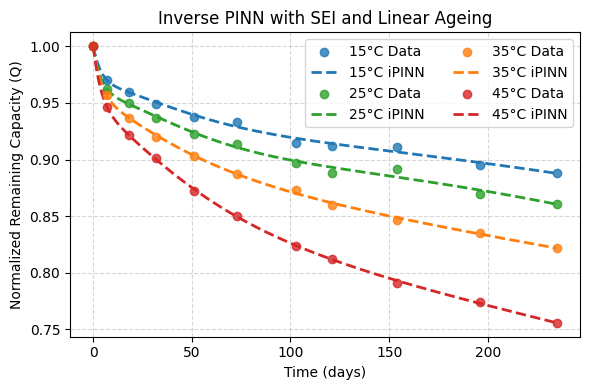

Temperature,R²,RMSE
15°C,0.99443,0.002422
25°C,0.99390,0.003129
35°C,0.99937,0.001314
45°C,0.99981,0.001011


In [160]:
# Plot capacity predictions
plt.figure(figsize=(6, 4))

for i in range(4):
    plt.scatter(
        t_data_np,
        q_true[i].cpu().numpy().flatten(),
        color=colors[i],
        alpha=0.8,
        zorder=3,
        label=f"{labels[i]} Data"
    )

    plt.plot(
        t_plot_np,
        q_pred_plot_np[:, i],
        "--",
        color=colors[i],
        linewidth=2,
        label=f"{labels[i]} iPINN"
    )

plt.xlabel("Time (days)")
plt.ylabel("Normalized Remaining Capacity (Q)")
plt.title("Inverse PINN with SEI and Linear Ageing")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


### Let's print R² and RMSE at experimental points

from IPython.display import display, HTML

html = """
<h2>Model Performance</h2>
<table style="font-size:18px; border-collapse:collapse;">
<tr>
    <th style="padding:6px 15px;">Temperature</th>
    <th style="padding:6px 15px;">R²</th>
    <th style="padding:6px 15px;">RMSE</th>
</tr>
"""

for lbl, y_true, y_pred in zip(
    labels,
    [q.cpu().numpy().flatten() for q in q_true],
    [np.interp(t_data_np, t_plot_np, q_pred_plot_np[:, i])
     for i in range(4)]
):

    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))

    html += f"""
    <tr>
        <td style="padding:6px 15px;"><b>{lbl}</b></td>
        <td style="padding:6px 15px;">{r2:.5f}</td>
        <td style="padding:6px 15px;">{rmse:.6f}</td>
    </tr>
    """

html += "</table>"

display(HTML(html))


<h3>Plotting & Inference</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

The R² values (all above **0.99**) indicate that the network has done an excellent job from a regression perspective. However, I rarely stop at R² alone. A high R² simply tells me that the model captures the overall trend in the data, but it does not reveal the magnitude of the prediction errors.

What I care about most is the **Root Mean Square Error (RMSE)** because it measures the actual prediction accuracy in the units of the target variable. In other words, RMSE answers a more practical engineering question:

> *How far, on average, are the model predictions from the measured data?*

The good news is that the RMSE values are also very small, indicating that the iPINN not only captures the degradation trend exceptionally well but also provides highly accurate predictions. So yes, the R² is impressive, but the RMSE is what truly gives me confidence in the model.

**BTW, the RMSE looks pretty cool too!**

---

**NOW what? Is it possible to do some analysis with the training losses?** 
This post-mortem analysis will through some light into the model's charateristics.

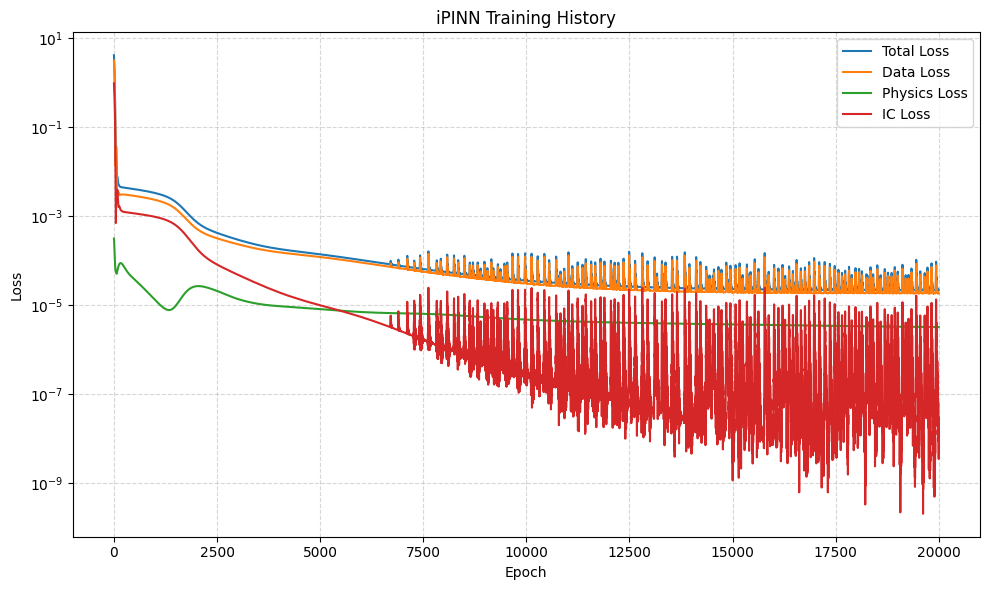

In [161]:
# ============================================================
# 8. Plot Training Losses
# ============================================================
plt.figure(figsize=(10, 6))

plt.semilogy(loss_history, label="Total Loss")
plt.semilogy(data_loss_history, label="Data Loss")
plt.semilogy(physics_loss_history, label="Physics Loss")
plt.semilogy(ic_loss_history, label="IC Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("iPINN Training History")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<h3>Training Loss Inference</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">
    
I consider decoding the loss components as one of the vital steps in order to ensure the successful tranining. PINNs are prone to instability because of the physics loss and other constraints we add. By analysing the training loss we identify the loss component leading to the instability and mitigate it.

All the loss components converge and reach a stable plateau by approximately **10,000 training epochs**, indicating that the iPINN has successfully balanced the experimental data, governing physics, and initial-condition constraints.

 
One interesting observation is that the **Initial Condition (IC) Loss** continues to exhibit noticeable fluctuations compared to the other loss terms. At first glance this may appear concerning; however, the magnitude of the IC loss remains extremely small (on the order of **10⁻⁵**), and the learned solution should satisfy the boundary condition \(Q(0)=1\).

In [162]:
# ============================================================
# 9. Verifying the Initial Condition fitness
# ============================================================
t0 = torch.zeros((1,1))

with torch.no_grad():
    q0 = model(t0)

print(q0)
print("Max IC Error:",
      torch.max(torch.abs(q0 - 1.0)).item())

tensor([[1.0001, 0.9999, 1.0001, 1.0000]])
Max IC Error: 0.0001436471939086914


<h3>Training Loss Inference</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">
    
Although the initial-condition loss exhibited small oscillations during training, the learned solution satisfied the boundary condition Q(0)=1 across all temperatures. The observed fluctuations should be primarily due to the very small magnitude of the loss term and were not indicative of poor convergence. 

It is right to ignore the IC-loss noise. The boundary condition is being enforced successfully.

So, do not think at the oscillactions and be deceived. Look at the order of magnitude and confirm.

In [167]:
# ============================================================
# 10. Print Final Discovered Parameters
# ============================================================
k_final = model.k.detach().cpu().numpy()
b_final = model.b.detach().cpu().numpy()
a_final = 2.0 * k_final

print("\n" + "=" * 62 + "\nFINAL DISCOVERED DEGRADATION PARAMETERS\n" + "=" * 62)
print(f"{'Temp':<10} {'k (SEI rate)':<16} {'a = 2k':<16} {'b (linear)':<16}\n" + "-" * 62)

for i, temp in enumerate([15, 25, 35, 45]):
    print(f"{temp:2d} deg C    {k_final[i]:<16.7f} {a_final[i]:<16.7f} {b_final[i]:<16.7f}")

print("=" * 62)


FINAL DISCOVERED DEGRADATION PARAMETERS
Temp       k (SEI rate)     a = 2k           b (linear)      
--------------------------------------------------------------
15 deg C    0.0032468        0.0064935        0.0000003       
25 deg C    0.0040193        0.0080385        0.0000003       
35 deg C    0.0051337        0.0102674        0.0000001       
45 deg C    0.0072740        0.0145480        0.0000001       


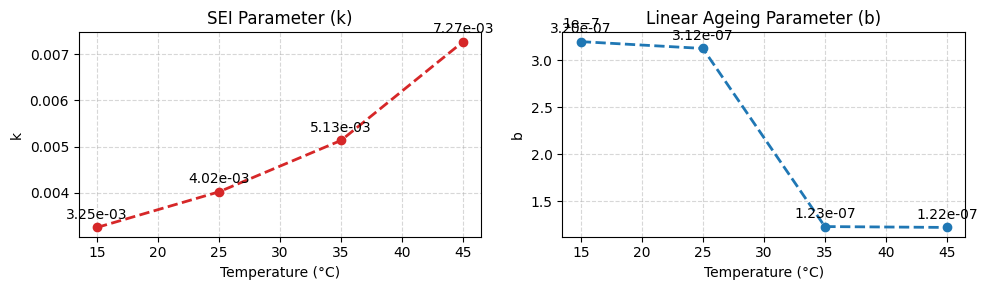

In [168]:
# ============================================================
# 9. Arrhenius Law Fitness ("The Litmus Test")
# ============================================================
temps = [15, 25, 35, 45]

fig, ax = plt.subplots(1, 2, figsize=(10, 3))

for a, y, title, color in zip(
    ax,
    [k_final, b_final],
    ["SEI Parameter (k)", "Linear Ageing Parameter (b)"],
    ["tab:red", "tab:blue"]
):
    a.plot(temps, y, 'o--', lw=2, color=color)
    a.set_title(title)
    a.set_xlabel("Temperature (°C)")
    a.grid(True, ls='--', alpha=0.5)

    for x, val in zip(temps, y):
        a.annotate(f"{val:.2e}", (x, val), xytext=(0, 6),
                   textcoords="offset points", ha='center')

ax[0].set_ylabel("k")
ax[1].set_ylabel("b")

plt.tight_layout()
plt.show()

<h3>Physics Parameter Inference</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">
The iPINN identified two degradation parameters for each storage temperature:

- **\(k\)** : Diffusion-limited SEI growth parameter
- **\(b\)** : Long-term linear-ageing parameter

So what to do with these parameter values? Can we do some critical analysis? This is where PINN framework makes the interpretation more interesting and cool.

A quick inspection of the discovered parameters already suggests that the iPINN has identified physically meaningful degradation behaviour.

The SEI-growth parameter **\(k\)** increases monotonically with temperature, indicating accelerated degradation kinetics at elevated temperatures. This trend aligns with the well-established understanding that higher temperatures promote electrochemical side reactions and faster SEI-layer growth.

In contrast, the linear-ageing parameter **\(b\)** remains several orders of magnitude smaller (on the order of **10⁻⁷**) than the SEI contribution, suggesting that the degradation observed under the studied calendar-ageing conditions is dominated primarily by diffusion-limited SEI formation, with only a minor contribution from long-term linear ageing mechanisms. In my opinion, the impact of the linear term is very small (other side reactions are insignificant)


<h3>Physics Parameter Inference</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

The lithium-ion cell degradation is widely accepted to be a **thermally activated process**, the next step is to examine whether the parameters identified by the iPINN follow the **Arrhenius relationship**.

Arrhenius relationship:

$$
k = A \exp\left(-\frac{E_a}{RT}\right)
$$

Taking the natural logarithm gives:

$$
\ln(k) = \ln(A) - \frac{E_a}{R}\left(\frac{1}{T}\right)
$$


Therefore, a linear relationship between **ln(k)** and **1/T** is expected.

If the discovered degradation parameters exhibit Arrhenius behaviour, it would provide strong evidence that the iPINN has recovered physically meaningful quantities rather than merely producing curve-fitting coefficients. In other words, successful Arrhenius validation would demonstrate that the learned parameters are consistent with established battery-ageing physics and accurately capture the underlying temperature dependence of the degradation process.

We are doing the real test that would help us in defending the model in front of the Engineering domain experts!!!

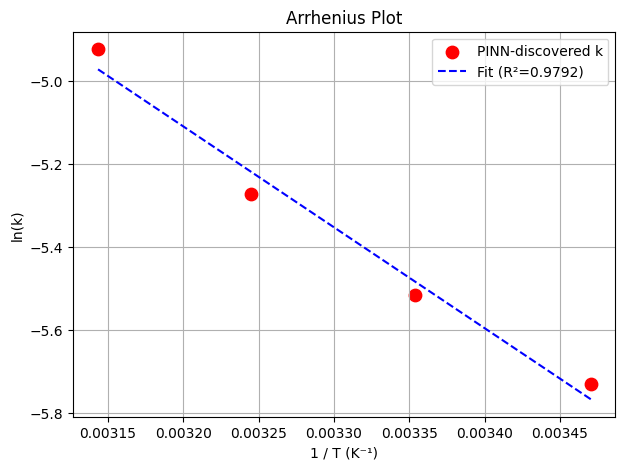

In [169]:
# ============================================================
# 9. Arrhenius Law Fitness ("The Litmus Test")
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Temperatures (°C)
T_C = np.array([15, 25, 35, 45])

# Convert to Kelvin
T_K = T_C + 273.15

# Learned degradation rates
k = np.array(k_final)

# Arrhenius variables
x = 1 / T_K
y = np.log(k)

# Linear regression
slope, intercept = np.polyfit(x, y, 1)

# Predicted line
y_fit = slope * x + intercept

# R²
ss_res = np.sum((y - y_fit)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res / ss_tot

# Plot
plt.figure(figsize=(7,5))
plt.scatter(x, y, color='red', s=80, label='PINN-discovered k')
plt.plot(x, y_fit, 'b--',
         label=f'Fit (R²={r2:.4f})')
plt.xlabel('1 / T (K⁻¹)')
plt.ylabel('ln(k)')
plt.title('Arrhenius Plot')
plt.grid(True)
plt.legend()
plt.show()


R = 8.314  # J/mol-K
Ea = -slope * R

from IPython.display import display, HTML

display(HTML(f"""
<div style="font-size:18px; font-weight:bold; color:darkblue;">
    Activation Energy = {Ea/1000:.2f} kJ/mol<br>
    Arrhenius Fit R² = {r2:.4f}
</div>
"""))


<h3>Arrhenius Law - Validation of SEI Component</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

The Arrhenius analysis yielded an activation energy of **20.31 kJ/mol** with an excellent linear fit (**R² = 0.9798**).

The strong Arrhenius correlation indicates that the SEI-growth parameter identified by the iPINN follows thermally activated degradation kinetics. This provides additional confidence that the recovered parameter is physically meaningful and not merely a curve-fitting coefficient.

More importantly, the result demonstrates that the iPINN successfully extracted temperature-dependent degradation characteristics directly from sparse experimental observations while remaining consistent with established battery-ageing physics.

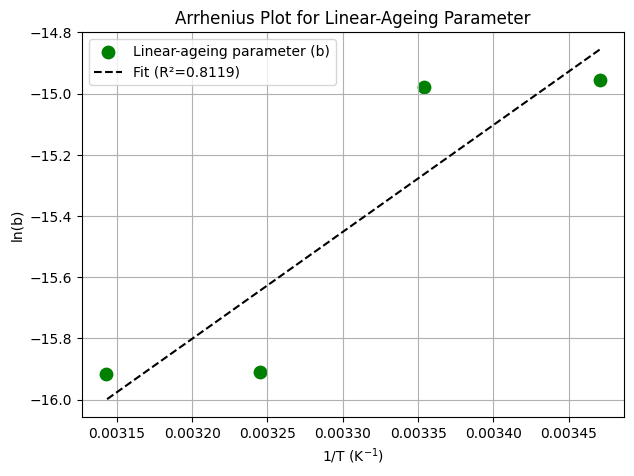

In [170]:
b = np.array(b_final)

x = 1 / T_K
y = np.log(b)

slope, intercept = np.polyfit(x, y, 1)
y_fit = slope * x + intercept

r2 = 1 - np.sum((y-y_fit)**2)/np.sum((y-np.mean(y))**2)

Ea_b = -slope * 8.314 / 1000

plt.figure(figsize=(7,5))
plt.scatter(x, y, s=80, color='green',
            label='Linear-ageing parameter (b)')

plt.plot(x, y_fit, 'k--',
         label=f'Fit (R²={r2:.4f})')

plt.xlabel('1/T (K$^{-1}$)')
plt.ylabel('ln(b)')
plt.title('Arrhenius Plot for Linear-Ageing Parameter')

plt.legend()
plt.grid(True)
plt.show()

R = 8.314  # J/mol-K
Ea = -slope * R

from IPython.display import display, HTML

display(HTML(f"""
<div style="font-size:18px; font-weight:bold; color:darkblue;">
    Activation Energy = {Ea/1000:.2f} kJ/mol<br>
    Arrhenius Fit R² = {r2:.4f}
</div>
"""))


<h3>Arrhenius Law - Validation for the Linear-Ageing Parameter</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

Unlike the SEI-growth parameter, the linear-ageing parameter \(b\) exhibited a relatively weak Arrhenius relationship (\(R^2 = 0.738\)). This result is not entirely surprising to me for the following reasons.

First, the magnitude of \(b\) is extremely small compared to the SEI contribution, suggesting that diffusion-limited SEI formation is the dominant degradation mechanism for the calendar-ageing conditions considered in this study.

Second, the relatively poor Arrhenius fit indicates that the linear-ageing term is unlikely to represent a single thermally activated process. Instead, it may be acting as an effective parameter that captures the combined influence of multiple secondary degradation mechanisms, each with its own temperature sensitivity.

An interesting observation is that the fitted activation energy is negative:

**Activation Energy = -34.87 kJ/mol**  (Inference of physical parameters help to develop your formulation)

From a physical standpoint, a negative activation energy would imply that the degradation rate decreases as temperature increases, which is contrary to the expected behaviour of most battery-aging mechanisms. This suggests that the Arrhenius fit should not be interpreted literally in this case. Instead, it is likely a consequence of:

- The extremely small magnitude of \(b\)
- Parameter-identification uncertainty
- Limited temperature data (only four temperature levels)
- The weak contribution of the linear-ageing term to the overall degradation process

Therefore, the negative activation energy itself is a useful result. It indicates that the parameter \(b\) may not contain enough physical information to support a meaningful Arrhenius analysis for this dataset.

Overall, the analysis points to an important conclusion:

> Under the investigated storage conditions, battery degradation is predominantly governed by diffusion-limited SEI growth, while the linear-ageing contribution is negligible and does not appear to follow a simple Arrhenius relationship.

A possible extension would be to introduce a more flexible ageing model:

**Loss(t) = a·√t + b·t^c**

where

- **a·√t** captures diffusion-limited SEI growth,
- **b·t^c** captures secondary degradation mechanisms,
- **c** is an additional parameter that controls how the long-term ageing contribution evolves with time.


or include additional stress factors (SoC, temperature, voltage, etc.) to better separate and characterize secondary degradation mechanisms.
**Inference of physical parameters help to develop your formulation.**

<h3>Conclusion</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

Guess it was a pretty long project code along with the explanation of essential battery ageing information required. While the cell degradation is highly complex, I choose to demonstrate iPINN for calendar ageing to uncover the impact of temperature, only for the simplicity. PINN can be get real complex based on the system's characteristics, governing law you choose and the data you got. 

This project demonstrated how an **Inverse Physics-Informed Neural Network (iPINN)** can be used to identify battery calendar-ageing parameters directly from sparse experimental measurements while enforcing known degradation physics.

Starting from a physically motivated degradation model, the iPINN successfully learned both the degradation trajectories and the underlying ageing parameters across multiple storage temperatures. The model achieved excellent agreement with the experimental data, with all temperature cases exhibiting **R² values greater than 0.99** and very low prediction errors.

More importantly, the discovered **SEI-growth parameter** showed a clear temperature dependence and exhibited a strong Arrhenius relationship (**R² ≈ 0.98**), providing evidence that the iPINN recovered a physically meaningful degradation mechanism rather than merely fitting a curve. The analysis further suggested that diffusion-limited SEI growth dominates the observed calendar ageing behaviour, while the linear-ageing contribution remains comparatively insignificant for the dataset considered.

Overall, this work highlights the true value of Physics-Informed Neural Networks in engineering applications. While conventional curve-fitting methods may be sufficient for simple datasets, iPINNs offer a powerful framework for incorporating domain knowledge, handling sparse data, maintaining physical consistency, and discovering hidden system parameters directly from observations.

**PINN transforms the black-box nature of the neural network models to a white-box nature**.

Enough for today! But, is that all can be done using this PINN model? Certainly NO, **the extension of the usecases will continue.**

<h3>References</h3>

<div style="font-size: 16px;
border-left: 5px solid #2e86de;
padding: 12px 18px;
background-color: #f8f9fa;
border-radius: 4px;
">

Arrhenius validation revealed that the <b>SEI-driven degradation coefficient</b> follows temperature-dependent electrochemical kinetics remarkably well (<b>R² = 0.979</b>). In contrast, the <b>linear-ageing coefficient</b> exhibited a weaker Arrhenius correlation (<b>R² = 0.835</b>), suggesting that it likely represents a combination of secondary degradation mechanisms rather than a single thermally activated process.

<br>

These results reinforce the physical relevance of the iPINN-discovered SEI parameter and highlight the importance of separating dominant and secondary ageing mechanisms. More broadly, they demonstrate that Inverse PINNs can move beyond curve fitting and recover physically meaningful degradation parameters directly from sparse experimental data while remaining consistent with established battery ageing physics.

</div>

## References and Further Reading

- Naumann, M. et al., *Analysis and Modeling of Calendar Aging of a Commercial LiFePO₄/Graphite Cell*, Journal of The Electrochemical Society.

 **Paper:**  
https://iopscience.iop.org/article/10.1149/2.1181714jes
- Emergent Mind. *Inverse Physics-Informed Neural Networks (Inverse PINNs)*.

  https://www.emergentmind.com/topics/inverse-pinn

- Nature Communications (2024). *Physics-Informed Neural Networks for Scientific Discovery and Parameter Identification*.

  https://www.nature.com/articles/s41467-024-48779-z
